# M0 · simulation — grasp poses

Design the grasps here, then hand them to the hardware. Output of this notebook is
`../poses.json`; [`../physical/grasp_poses.ipynb`](../physical/grasp_poses.ipynb) replays that
file on the real hand and writes back what the hand actually reached.

**Stack:** `pydrake` + `Meshcat` + `matplotlib`. Kinematics only — no contact, no physics, so
these poses are *geometric candidates*, not verified grasps. Verifying them is the hardware
notebook's job, and the gap between the two is the number worth knowing before M1.

What "gap" means here: the distance between two fingertip **link origins**, not between the pad
surfaces. The fingers already touch at roughly 15 mm, so read the numbers as relative and
confirm the pose visually in Meshcat.

In [1]:
import sys
from pathlib import Path

# Locate src/m0 whether the kernel started in this folder, in the repo root, or anywhere between.
# Matched by content, not by folder name, so it survives m0/M0 casing differences between
# a case-insensitive mac and the case-sensitive robot PC.
_here = [Path.cwd(), *Path.cwd().parents]
_candidates = [*_here, *(p / "src" / name for p in _here for name in ("m0", "M0"))]
M0_DIR = next((p for p in _candidates if (p / "hand_model.py").exists()), None)
if M0_DIR is None:
    raise RuntimeError(f"could not find src/m0 from {Path.cwd()}; open this notebook from its own folder")
for _path in (M0_DIR, M0_DIR / "simulation"):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import numpy as np

from hand_model import FINGER_NAMES, POSE_LIBRARY_PATH, describe, load_poses, save_pose
from sim_hand import DEFAULT_BRICK, SimHand, SimHandUI, aperture_curve, closure_for_gap, launch_meshcat

meshcat = launch_meshcat()
sim = SimHand(meshcat, brick_urdf=DEFAULT_BRICK)
ui = SimHandUI(sim)
ui

INFO:drake:Meshcat listening for connections at http://localhost:7001


Meshcat started at http://localhost:7001


## What is in the library today

Presets ship in `hand_model.PRESETS`; anything you save shadows them by name.

In [2]:
poses = load_poses()

header = f"{'name':16s} " + " ".join(f"{n:>9s}" for n in FINGER_NAMES) + f"{'th-idx':>9s}{'th-mid':>9s}"
print(header)
print("-" * len(header))
for name, pose in sorted(poses.items()):
    sim.set_pose(pose)
    values = " ".join(f"{v:9.2f}" for v in pose)
    print(f"{name:16s} {values}{sim.gap_mm():9.1f}{sim.gap_mm('thumb', 'middle'):9.1f}")

sim.set_pose(ui.pose)

name                 thumb thumb_aux     index    middle      ring     pinky   th-idx   th-mid
----------------------------------------------------------------------------------------------
fist                  1.00      1.00      1.00      1.00      1.00      1.00     55.0     51.4
grasp_1x1_brick       0.47      0.80      0.47      0.00      0.00      0.00     22.4     97.4
grasp_1x2_brick       0.47      0.80      0.47      0.00      0.00      0.00     22.4     97.4
grasp_1x4_plate       0.47      0.80      0.47      0.00      0.00      0.00     22.4     97.4
grasp_2x2_brick       0.42      0.80      0.42      0.00      0.00      0.00     29.8    101.5
grasp_2x4_brick       0.42      0.80      0.42      0.00      0.00      0.00     29.8    101.5
lego_pinch            0.54      0.80      0.54      0.00      0.00      0.00     15.3     90.0
open                  0.00      0.00      0.00      0.00      0.00      0.00    132.0    156.5
pinch                 0.50      0.80      0.50    

array([0.5, 0.8, 0.5, 0.5, 0. , 0. ])

## Aperture calibration

Closing thumb and index together is **not** monotonic: past a certain closure the fingertips
swing past each other and the gap opens up again. So "close harder" is not the same as "grip
tighter", and any M1 controller that assumes it will be wrong.

The sweep below finds, for each thumb abduction (`thumb_aux`), the closure that brings the
fingertips closest and how close that is.

In [3]:
aux_values = np.round(np.linspace(0.4, 1.0, 7), 2)

print(f"{'thumb_aux':>10}  {'best closure':>12}  {'min gap mm':>11}")
best = {}
for aux in aux_values:
    closures, gaps = aperture_curve(sim, thumb_aux=float(aux))
    i = int(np.argmin(gaps))
    best[float(aux)] = (float(closures[i]), float(gaps[i]))
    print(f"{aux:10.2f}  {closures[i]:12.2f}  {gaps[i]:11.1f}")

best_aux = min(best, key=lambda a: best[a][1])
print(f"\nmost opposed thumb: thumb_aux = {best_aux} -> {best[best_aux][1]:.1f} mm at closure {best[best_aux][0]:.2f}")

 thumb_aux  best closure   min gap mm
      0.40          0.60         38.3
      0.50          0.58         31.5
      0.60          0.56         24.6
      0.70          0.54         18.8
      0.80          0.54         15.3
      0.90          0.54         16.6
      1.00          0.54         21.6

most opposed thumb: thumb_aux = 0.8 -> 15.3 mm at closure 0.54


Small multiples of the same curve — one panel per thumb abduction, one hue, minimum marked.
The point to read off: how *sharp* the minimum is. A flat bottom means the grasp tolerates
command error; a sharp one means it will not.

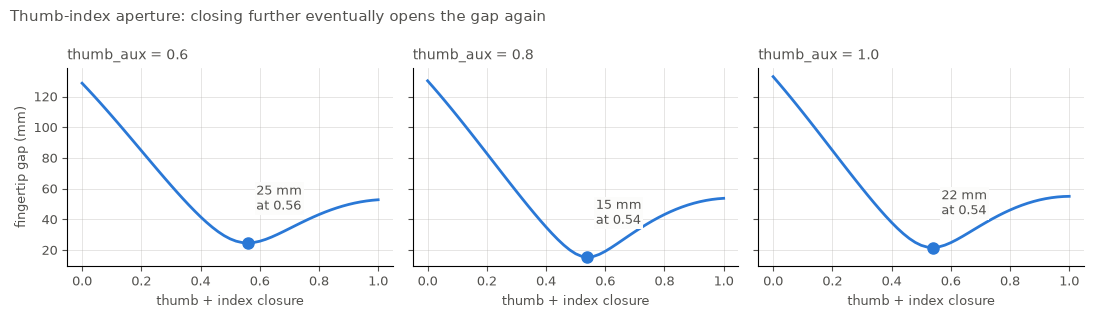

array([0.5, 0.8, 0.5, 0.5, 0. , 0. ])

In [4]:
import matplotlib.pyplot as plt

ACCENT, INK, MUTED = "#2a78d6", "#52514e", "#b8b7b2"
panels = [0.6, 0.8, 1.0]

fig, axes = plt.subplots(1, len(panels), figsize=(11, 3.2), sharey=True)
for ax, aux in zip(axes, panels):
    closures, gaps = aperture_curve(sim, thumb_aux=aux)
    i = int(np.argmin(gaps))
    ax.plot(closures, gaps, color=ACCENT, linewidth=2)
    ax.plot(closures[i], gaps[i], "o", color=ACCENT, markersize=8)
    ax.annotate(f"{gaps[i]:.0f} mm\nat {closures[i]:.2f}", (closures[i], gaps[i]),
                textcoords="offset points", xytext=(6, 24), color=INK, fontsize=9,
                bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1))
    ax.set_title(f"thumb_aux = {aux}", color=INK, fontsize=10, loc="left")
    ax.set_xlabel("thumb + index closure", color=INK, fontsize=9)
    ax.grid(True, color=MUTED, linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(colors=INK, labelsize=9)

axes[0].set_ylabel("fingertip gap (mm)", color=INK, fontsize=9)
fig.suptitle("Thumb-index aperture: closing further eventually opens the gap again",
             color=INK, fontsize=11, x=0.01, ha="left")
fig.tight_layout()
plt.show()

sim.set_pose(ui.pose)

## Sizing a pinch to a brick

Nominal LEGO geometry: the stud pitch is 8.0 mm and plate height 3.2 mm, so a 1×1 brick is
8×8×9.6 mm and a 2×4 is 31.8×15.8×9.6 mm (the 0.2 mm is manufacturing clearance).

`closure_for_gap` walks the *closing* branch of the curve and returns the first closure whose
fingertip gap reaches the target. Add a margin: the pads make contact well before the origins
coincide, so target roughly the brick dimension **plus** the ~15 mm floor.

In [5]:
BRICK_DIMENSIONS_MM = {          # the dimension you would pinch across
    "1x1 brick": 8.0,
    "1x2 brick": 8.0,
    "2x2 brick": 15.8,
    "2x4 brick": 15.8,
    "1x4 plate": 8.0,
}
CONTACT_FLOOR_MM = 15.0          # fingertip origins still ~15 mm apart when the pads touch

print(f"{'brick':12s} {'width mm':>9s} {'target gap':>11s} {'closure':>8s}")
grasps = {}
for label, width in BRICK_DIMENSIONS_MM.items():
    target = width + CONTACT_FLOOR_MM
    closure = closure_for_gap(sim, target, thumb_aux=float(best_aux))
    grasps[label] = closure
    shown = f"{closure:8.2f}" if closure is not None else "     n/a"
    print(f"{label:12s} {width:9.1f} {target:11.1f} {shown}")

brick         width mm  target gap  closure
1x1 brick          8.0        23.0     0.47
1x2 brick          8.0        23.0     0.47
2x2 brick         15.8        30.8     0.42
2x4 brick         15.8        30.8     0.42
1x4 plate          8.0        23.0     0.47


## Look at it, then save it

Put the brick between the fingertips and check the pose in Meshcat before committing it — the
numbers cannot tell you that the thumb is passing *beside* the brick rather than onto it.

In [6]:
closure = grasps["2x4 brick"]
pose = {"thumb": closure, "thumb_aux": float(best_aux), "index": closure}

ui.set_pose(pose)
sim.place_brick_between()
print(describe(sim.pose))
print(f"gap {sim.gap_mm():.1f} mm  ->  check the Meshcat view now")

thumb=0.42( 25deg)  thumb_aux=0.80( 72deg)  index=0.42( 34deg)  middle=0.00(  0deg)  ring=0.00(  0deg)  pinky=0.00(  0deg)
gap 29.8 mm  ->  check the Meshcat view now


In [7]:
# Commit the sized grasps to ../poses.json for the physical stack to replay.
for label, closure in grasps.items():
    if closure is None:
        continue
    name = "grasp_" + label.replace(" ", "_")
    save_pose(name, {"thumb": closure, "thumb_aux": float(best_aux), "index": closure})

library = load_poses()
print(f"{POSE_LIBRARY_PATH} now holds:")
for name in sorted(library):
    print(f"  {name:22s} {np.array2string(library[name], precision=2)}")

/Users/chaseungjun/everything/Code/int2026/src/m0/poses.json now holds:
  fist                   [1. 1. 1. 1. 1. 1.]
  grasp_1x1_brick        [0.47 0.8  0.47 0.   0.   0.  ]
  grasp_1x2_brick        [0.47 0.8  0.47 0.   0.   0.  ]
  grasp_1x4_plate        [0.47 0.8  0.47 0.   0.   0.  ]
  grasp_2x2_brick        [0.42 0.8  0.42 0.   0.   0.  ]
  grasp_2x4_brick        [0.42 0.8  0.42 0.   0.   0.  ]
  lego_pinch             [0.54 0.8  0.54 0.   0.   0.  ]
  open                   [0. 0. 0. 0. 0. 0.]
  pinch                  [0.5 0.8 0.5 0.  0.  0. ]
  point                  [0.6 0.8 0.  1.  1.  1. ]
  power                  [0.8 0.6 0.9 0.9 0.9 0.9]
  tripod                 [0.5 0.8 0.5 0.5 0.  0. ]


## Next

Take `../poses.json` to the bench: [`../physical/grasp_poses.ipynb`](../physical/grasp_poses.ipynb)
replays each of these, records what the hand actually reached and at what current, and writes
`../poses_measured.json`. The difference between the two files is your sim-to-real error for M1.